In [ ]:
#Importação das bibliotecas necessárias
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score




In [10]:
#Leitura dos arquivos CSV
df_prod = pd.read_csv(r"C:\Users\Bruno\OneDrive - PUCRS - BR\Documentos\Projeto-Em-Business-Intelligence-e-Analytics\data\dados_producao_agricola\dados_producao_noroeste_RS.csv")
df_clima = pd.read_csv(r"C:\Users\Bruno\OneDrive - PUCRS - BR\Documentos\Projeto-Em-Business-Intelligence-e-Analytics\data\dados_metereologicos\dados_rs_tratados\dados_meteorologia_RS.csv")
df_geo = pd.read_csv(r"C:\Users\Bruno\OneDrive - PUCRS - BR\Documentos\Projeto-Em-Business-Intelligence-e-Analytics\data\daos_geograficos\dados_tratados\dados_geograficos_RS.csv")



In [11]:
#Padronização dos dados
df_geo['codigo_municipio'] = df_geo['codigo_municipio'].astype(str)
df_prod['cod_municipio'] = df_prod['cod_municipio'].astype(str)

df_geo['nome_municipio'] = df_geo['nome_municipio'].str.upper().str.strip()
df_clima['cidade'] = df_clima['cidade'].str.upper().str.strip()

df_geo['nome_municipio'] = df_geo['nome_municipio'].str.upper().str.strip()


In [12]:
display(df_prod)

,Unidade de Medida,valor,cod_municipio,ano,variavel,produto
0,Hectares,1500.0,4300034,2010,Área plantada,Milho
1,Hectares,2100.0,4300034,2010,Área plantada,Soja
2,Hectares,700.0,4300034,2010,Área plantada,Trigo
3,Hectares,1500.0,4300034,2010,Área colhida,Milho
4,Hectares,2100.0,4300034,2010,Área colhida,Soja
...,...,...,...,...,...,...
112019,Hectares,240.0,4323804,2023,Área plantada,Soja
112020,Hectares,240.0,4323804,2023,Área colhida,Soja
112021,Toneladas,864.0,4323804,2023,Quantidade produzida,Soja
112022,Quilogramas por Hectare,3600.0,4323804,2023,Rendimento médio da produção,Soja


In [16]:
#Tratamento dos dados de produção agricola
df_prod = df_prod[df_prod['variavel'] == 'Rendimento médio da produção']

df_prod = df_prod.pivot_table(
    index=['cod_municipio', 'ano'],
    columns='produto',
    values='valor',
    aggfunc='sum'
).reset_index()

df_prod.columns.name = None

display(df_prod)

,cod_municipio,ano,Fumo,Milho,Soja,Trigo
0,4300034,2010,NaN,1380.0,1750.0,2100.0
1,4300034,2011,NaN,1200.0,2400.0,2100.0
2,4300034,2012,NaN,2100.0,1460.0,2100.0
3,4300034,2013,NaN,2100.0,2100.0,2000.0
4,4300034,2014,NaN,4000.0,2300.0,1800.0
...,...,...,...,...,...,...
7352,4323770,2024,NaN,6480.0,2968.0,1320.0
7353,4323804,2010,NaN,1600.0,NaN,NaN
7354,4323804,2011,NaN,1600.0,NaN,NaN
7355,4323804,2012,NaN,1600.0,NaN,NaN


In [17]:
#Tratamentod de dados meteorológicos (diário → anual)
df_clima['data'] = pd.to_datetime(df_clima['data'], errors='coerce')

df_clima_ano = df_clima.groupby(['cidade', 'ano']).agg({
    'precipitacao': ['sum', 'mean', 'std'],
    'temperatura': ['mean', 'max', 'min'],
    'umidade': ['mean'],
    'vento': ['mean']
}).reset_index()

# flatten colunas
df_clima_ano.columns = [
    'cidade', 'ano',
    'prec_total', 'prec_media', 'prec_std',
    'temp_media', 'temp_max', 'temp_min',
    'umidade_media',
    'vento_media'
]

df_clima_ano['cidade'] = df_clima_ano['cidade'].str.upper().str.strip()

display(df_clima_ano)

,cidade,ano,prec_total,prec_media,prec_std,temp_media,temp_max,temp_min,umidade_media,vento_media
0,ALEGRETE,2014,349.0,0.956164,4.808217,19.707557,35.0,4.50,75.707340,2.206605
1,ALEGRETE,2015,334.0,0.915068,3.577389,19.322688,33.0,5.00,75.039734,2.199992
2,ALEGRETE,2016,337.0,0.920765,3.819454,19.043646,34.2,4.00,73.903119,2.142441
3,ALEGRETE,2017,201.0,0.550685,2.362896,19.907068,35.0,5.50,74.060348,2.244415
4,ALEGRETE,2018,317.0,0.868493,4.017027,19.164329,33.0,1.00,75.248700,2.175064
...,...,...,...,...,...,...,...,...,...,...
464,VACARIA,2020,284.0,0.775956,3.360377,16.294265,29.0,2.75,75.245073,3.011367
465,VACARIA,2021,364.0,0.997260,3.330263,15.544193,30.0,0.00,80.771174,2.744458
466,VACARIA,2022,364.0,0.997260,3.414174,15.065039,29.0,-1.00,81.502311,3.241056
467,VACARIA,2023,370.0,1.013699,3.910022,15.763426,29.0,1.00,82.406444,3.093757


In [18]:

df_clima_geo = df_clima_ano.merge(
    df_geo,
    left_on='cidade',
    right_on='nome_municipio',
    how='left'
)

df_clima_regiao = df_clima_geo.groupby(
    ['regiao_imediata', 'ano']
).agg({
    'prec_total': 'mean',
    'temp_media': 'mean',
    'umidade_media': 'mean',
    'vento_media': 'mean'
}).reset_index()

df_clima_regiao['regiao_imediata'] = df_clima_regiao['regiao_imediata'].astype(int)

display(df_clima_regiao)

,regiao_imediata,ano,prec_total,temp_media,umidade_media,vento_media
0,430001,2014,280.5,20.458153,75.582822,3.192411
1,430001,2015,357.5,20.297816,79.646504,3.275483
2,430001,2016,264.0,18.793295,79.890514,3.263076
3,430001,2017,300.0,20.460919,78.956537,3.435944
4,430001,2018,265.5,19.845050,79.766929,3.306482
...,...,...,...,...,...,...
203,430040,2020,196.0,18.985047,71.913338,2.700686
204,430040,2021,186.0,18.807567,73.043650,2.642291
205,430040,2022,219.5,18.224172,75.827485,2.545405
206,430040,2023,446.5,19.128378,77.198409,2.446412


In [19]:
#Merge entre as bases de dados

df = df_prod.merge(
    df_geo,
    left_on='cod_municipio',
    right_on='codigo_municipio',
    how='left'
)

df = df.merge(
    df_clima_regiao,
    on=['regiao_imediata', 'ano'],
    how='left'
)

display(df)

,cod_municipio,ano,Fumo,Milho,Soja,Trigo,uf,nome_uf,regiao_intermediaria,nome_regiao_intermediaria,regiao_imediata,nome_regiao_imediata,codigo_municipio,nome_municipio,uf_sigla,prec_total,temp_media,umidade_media,vento_media
0,4300034,2010,NaN,1380.0,1750.0,2100.0,43,Rio Grande do Sul,4302,Pelotas,430010,Bagé,4300034,ACEGUÁ,RS,NaN,NaN,NaN,NaN
1,4300034,2011,NaN,1200.0,2400.0,2100.0,43,Rio Grande do Sul,4302,Pelotas,430010,Bagé,4300034,ACEGUÁ,RS,NaN,NaN,NaN,NaN
2,4300034,2012,NaN,2100.0,1460.0,2100.0,43,Rio Grande do Sul,4302,Pelotas,430010,Bagé,4300034,ACEGUÁ,RS,NaN,NaN,NaN,NaN
3,4300034,2013,NaN,2100.0,2100.0,2000.0,43,Rio Grande do Sul,4302,Pelotas,430010,Bagé,4300034,ACEGUÁ,RS,NaN,NaN,NaN,NaN
4,4300034,2014,NaN,4000.0,2300.0,1800.0,43,Rio Grande do Sul,4302,Pelotas,430010,Bagé,4300034,ACEGUÁ,RS,246.0,18.736643,76.981346,3.356273
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7352,4323770,2024,NaN,6480.0,2968.0,1320.0,43,Rio Grande do Sul,4308,Santa Cruz do Sul - Lajeado,430041,Lajeado,4323770,WESTFÁLIA,RS,NaN,NaN,NaN,NaN
7353,4323804,2010,NaN,1600.0,NaN,NaN,43,Rio Grande do Sul,4301,Porto Alegre,430003,Tramandaí - Osório,4323804,XANGRI-LÁ,RS,NaN,NaN,NaN,NaN
7354,4323804,2011,NaN,1600.0,NaN,NaN,43,Rio Grande do Sul,4301,Porto Alegre,430003,Tramandaí - Osório,4323804,XANGRI-LÁ,RS,NaN,NaN,NaN,NaN
7355,4323804,2012,NaN,1600.0,NaN,NaN,43,Rio Grande do Sul,4301,Porto Alegre,430003,Tramandaí - Osório,4323804,XANGRI-LÁ,RS,NaN,NaN,NaN,NaN


In [25]:
#Remoção de registros sem dados meteorológicos

df = df.dropna(subset=['prec_total', 'temp_media', 'umidade_media'])

In [26]:
df_modelo = df[['prec_total', 'temp_media', 'umidade_media', 'Soja']].dropna()

df_modelo = df_modelo.rename(columns={'Soja': 'produtividade'})

Análise exploratória dos dados

Text(0.5, 1.0, 'Distribuição da Produtividade da Soja')

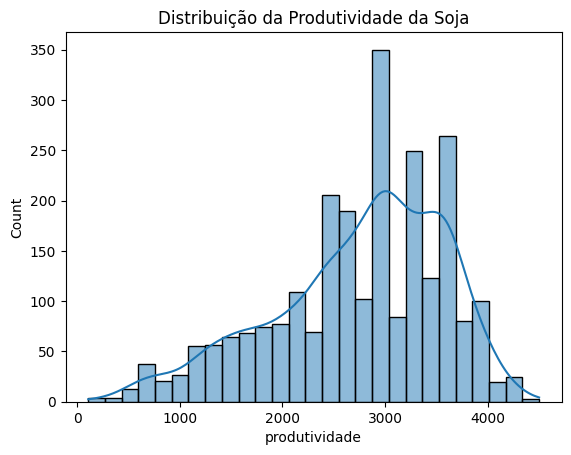

In [ ]:
#Análise exploratória dos dados

sns.histplot(df_modelo['produtividade'], kde=True)
plt.title('Distribuição da Produtividade da Soja')

Text(0.5, 1.0, 'Correlação')

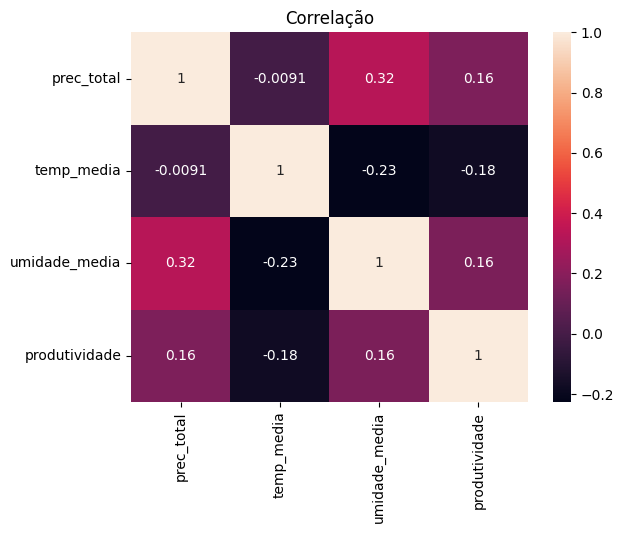

In [28]:
sns.heatmap(df_modelo.corr(), annot=True)
plt.title('Correlação')

Text(0.5, 1.0, 'Chuva vs Produtividade')

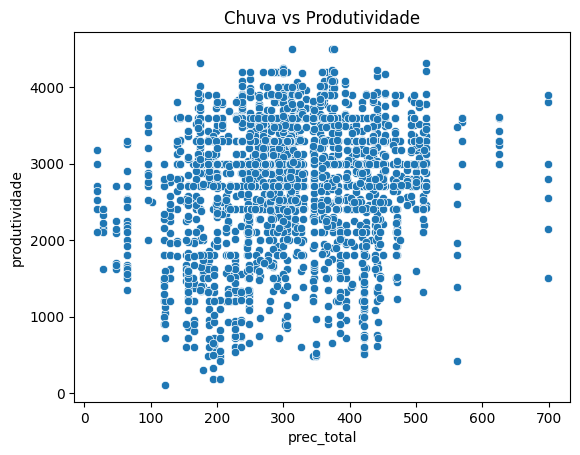

In [29]:
sns.scatterplot(x=df_modelo['prec_total'], y=df_modelo['produtividade'])
plt.title('Chuva vs Produtividade')

In [ ]:
#Criação de uma nova variável de clima

df_modelo['clima_score'] = (
    df_modelo['prec_total'] * 0.5 +
    df_modelo['temp_media'] * 0.3 +
    df_modelo['umidade_media'] * 0.2
)

In [ ]:
#Preparação dos dados para modelagem

target = 'produtividade'

features = ['prec_total', 'temp_media', 'umidade_media', 'clima_score']

X = df_modelo[features]
y = df_modelo[target]

In [ ]:
# Divisão entre treino e teste

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
#Treinamento do modelo

model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [ ]:
#Avaliação do modelo

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 368.5678040380648
R2: 0.6882766054196046


Text(0.5, 1.0, 'Importância das Variáveis')

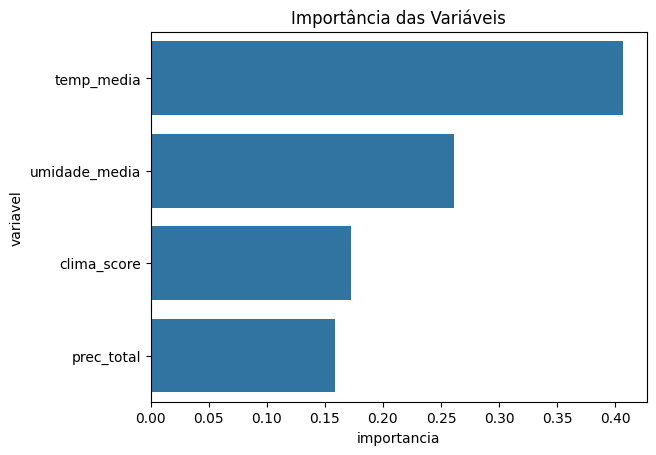

In [ ]:
#Importância das variáveis

importancias = pd.DataFrame({
    'variavel': features,
    'importancia': model.feature_importances_
}).sort_values(by='importancia', ascending=False)

sns.barplot(data=importancias, x='importancia', y='variavel')
plt.title('Importância das Variáveis')

In [ ]:
#Previsão para um novo dado

novo_dado = pd.DataFrame({
    'prec_total': [150],
    'temp_media': [24],
    'umidade_media': [75],
    'clima_score': [150*0.5 + 24*0.3 + 75*0.2]
})

previsao = model.predict(novo_dado)

print(f"Produção prevista: {previsao[0]:.2f}")

print(importancias)

Produção prevista: 1997.79
        variavel  importancia
1     temp_media     0.406760
2  umidade_media     0.261622
3    clima_score     0.172500
0     prec_total     0.159118
